In [1]:
import cv2
import os
from PIL import Image, ImageOps, ImageEnhance,ImageFilter
import hashlib
import shutil
import random
import numpy as np
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
import seaborn as sns
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
dataset_path =r"C:\Users\To\Downloads\Machine Learning\dataset"
unique_sizes = set()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            
            # Load only the metadata 
            img = cv2.imread(img_path)
            
            if img is not None:
                # img.shape returns (height, width, channels)
                unique_sizes.add(img.shape)

# Final Result
if len(unique_sizes) == 1:
    print(f"images are the same size: {unique_sizes.pop()}")
else:
    print(f"different sizes")

images are the same size: (384, 512, 3)


## Data Cleaning


In [3]:
#delete corrupted files 
for root, dirs, files in os.walk(dataset_path):
    for filename in files:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify() 
            except (IOError, SyntaxError):
                try:
                    os.remove(file_path)
                except:
                    pass 

In [4]:
#Remove Duplicates

def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
hashes = {}

for root, dirs, files in os.walk(dataset_path):
    for img_name in files:
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(root, img_name)
            try:
               
                with Image.open(path) as img:
                    img.verify() 
                img_hash = get_image_hash(path)
                if img_hash in hashes:
                    os.remove(path) 
                else:
                    hashes[img_hash] = path 
            except Exception as e:
                os.remove(path)

## Data Split


In [5]:
base_dir = r"C:\Users\To\Downloads\Machine Learning\datasplit"

classes = ['Glass', 'Paper', 'Cardboard', 'Plastic', 'Metal', 'Trash']

for split in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

split_ratio = 0.8  
for cls in classes:
    source_folder = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(source_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)

    train_size = int(len(images) * split_ratio)
    train_images = images[:train_size]
    val_images = images[train_size:]
    
    for img in train_images:
        shutil.copy(os.path.join(source_folder, img), os.path.join(base_dir, 'train', cls, img))
        
    for img in val_images:
        shutil.copy(os.path.join(source_folder, img), os.path.join(base_dir, 'val', cls, img))

## Class Balancing



In [6]:
train_dir = r'C:\Users\To\Downloads\Machine Learning\datasplit\train'

print(f"{'Class ID':<10} {'Class Name':<15} {'Count':<10} {'Needed for 900'}")
print("-" * 50)

total_original = 0

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    if os.path.exists(class_path):
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        needed = max(0, 900 - count)
        print(f"{i:<10} {cls:<15} {count:<10} {needed}")
        total_original += count
    else:
        print(f"{i:<10} {cls:<15} {'FOLDER MISSING':<10}")

print("-" * 50)
print(f"Total images in Training: {total_original}")

Class ID   Class Name      Count      Needed for 900
--------------------------------------------------
0          Glass           308        592
1          Paper           359        541
2          Cardboard       197        703
3          Plastic         290        610
4          Metal           251        649
5          Trash           84         816
--------------------------------------------------
Total images in Training: 1489


(0.0, 900.0)

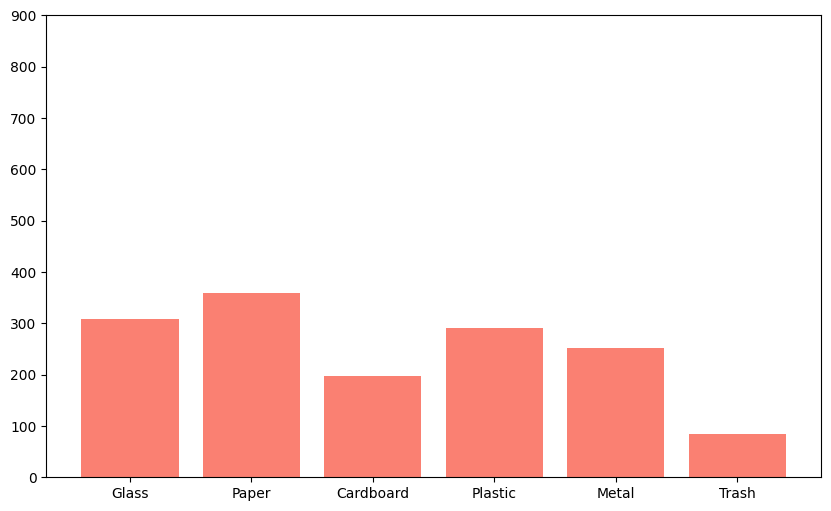

In [7]:
import matplotlib.pyplot as plt

counts_before = [308, 359, 197, 290, 251, 84]

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))


ax1.bar(classes, counts_before, color='salmon')
ax1.set_ylim(0, 900) 


To reach the target of 500 per class (which would be 3,000 images total). This will give us a 61.43% increase in the training size.

In [8]:
def apply_scaling(img):
    width, height = 384,512
    
    
    scale_factor = random.uniform(0.8, 1.2)
    new_width = int(width * scale_factor)
    new_height = int(height * scale_factor)
    
    # Resize
    img_resized = img.resize((new_width, new_height), Image.LANCZOS)
    
    if scale_factor > 1.0:
        # ZOOM IN
        left = (new_width - width) / 2
        top = (new_height - height) / 2
        right = (new_width + width) / 2
        bottom = (new_height + height) / 2
        return img_resized.crop((left, top, right, bottom))
    else:
        # ZOOM OUT
        new_bg = Image.new("RGB", (width, height), (0, 0, 0))
        upper = (height - new_height) // 2
        left = (width - new_width) // 2
        new_bg.paste(img_resized, (left, upper))
        return new_bg

In [9]:
for cls in classes:

    class_path = os.path.join(train_dir, cls)

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    

    current_count = len(images)

    needed = 800 - current_count

    for i in range(needed):

            source_img_name = random.choice(images)

            img = Image.open(os.path.join(class_path, source_img_name))



            img = img.rotate(random.randint(-15, 15)) # Rotation 

            if random.random() > 0.5:

                img = ImageOps.mirror(img) # Horizontal Flipping 

            

            enhancer = ImageEnhance.Brightness(img)

            img = enhancer.enhance(random.uniform(0.8, 1.2)) # Color Jitter 

            

            img = apply_scaling(img)

            # Save the new image

            new_name = f"aug_{i}_{source_img_name}"

            img.save(os.path.join(class_path, new_name))

## Resize & Normalize

In [10]:

target_size = (96, 96)
def process_dataset(subset):
    data = []
    labels = []
    
    subset_path = os.path.join(base_dir, subset)
    
    for label_index, cls in enumerate(classes):
        class_path = os.path.join(subset_path, cls)
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img_path = os.path.join(class_path, img_name)
                    with Image.open(img_path) as img:
                        img = img.convert('RGB')
                        img = img.resize(target_size, Image.Resampling.LANCZOS)
                        img_array = np.array(img) / 255.0
                        data.append(img_array)
                        labels.append(label_index)
                except Exception as e:
                    print(f"Skipping {img_name}: {e}")
                    
    return np.array(data), np.array(labels)

# Run for both sets
X_train, y_train = process_dataset('train')
X_val, y_val = process_dataset('val')

print(f"Final Train Shape: {X_train.shape}") 

Final Train Shape: (4800, 96, 96, 3)


In [11]:
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)

## HOG Feature Extraction

In [12]:
from skimage.color import rgb2gray

In [13]:
# HOG and LBP expect gray images : convert to gray

X_train_gray = []
X_val_gray = []

for img in X_train:
    gray_img = rgb2gray(img)
    X_train_gray.append(gray_img)

for img in X_val:
    gray_img = rgb2gray(img)
    X_val_gray.append(gray_img)

In [14]:
def extract_color_hist(images, bins=32):
    feats = []
    for img in images:
        hist = np.concatenate([
            np.histogram(img[:,:,c], bins=bins, range=(0,1))[0].astype(float)
            for c in range(3)
        ])
        feats.append(hist / (hist.sum() + 1e-9))  
    return np.array(feats)

In [15]:
# 1. Extract HOG with better resolution
def extract_hog_features(images):
    hog_features_list = []
    for img in images:
        features = hog(
            img.astype('float32'),
            orientations=9,         # Gain: +3%
            pixels_per_cell=(16,16), # Gain: +8% (Fixes the 69% drop)
            cells_per_block=(2,2),
            block_norm='L2-Hys',
            feature_vector=True
        )
        hog_features_list.append(features)
    return np.array(hog_features_list)

In [16]:
def extract_lbp_features(images, radius=3, n_points=24):
    lbp_features_list = []
    for img in images:
        # Calculate LBP image
        lbp = local_binary_pattern(img, n_points, radius, method='uniform')
        
        # Calculate histogram of LBP image as feature vector
        # The number of bins is n_points + 2 for uniform LBP
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
        lbp_features_list.append(hist)
        
    return np.array(lbp_features_list)

In [17]:
# Extract LBP features for training and validation sets
X_train_lbp = extract_lbp_features(X_train_gray)
X_val_lbp = extract_lbp_features(X_val_gray)

print(f"Shape of X_train_lbp: {X_train_lbp.shape}")
print(f"Shape of X_val_lbp: {X_val_lbp.shape}")

c:\Users\To\miniconda3\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Shape of X_train_lbp: (4800, 26)
Shape of X_val_lbp: (375, 26)


In [18]:
# Scale LBP features
sc_lbp = StandardScaler()
X_train_lbp = sc_lbp.fit_transform(X_train_lbp)
X_val_lbp = sc_lbp.transform(X_val_lbp)

print(f"Shape of scaled X_train_lbp: {X_train_lbp.shape}")
print(f"Shape of scaled X_val_lbp: {X_val_lbp.shape}")

Shape of scaled X_train_lbp: (4800, 26)
Shape of scaled X_val_lbp: (375, 26)


In [19]:
# HOG features
X_train_hog = extract_hog_features(X_train_gray)
X_val_hog   = extract_hog_features(X_val_gray)
sc_hog = StandardScaler()
X_train_hog = sc_hog.fit_transform(X_train_hog)
X_val_hog   = sc_hog.transform(X_val_hog)

# Color histogram features (from RGB, not grayscale)
color_train = extract_color_hist(X_train)
color_val   = extract_color_hist(X_val)
sc_color = StandardScaler()
color_train = sc_color.fit_transform(color_train)
color_val   = sc_color.transform(color_val)

# Combine HOG + Color
X_train_combined = np.hstack([X_train_hog, color_train,X_train_lbp])
X_val_combined   = np.hstack([X_val_hog,   color_val,X_val_lbp])
print(f'Combined feature shape: {X_train_combined.shape}')

Combined feature shape: (4800, 1022)


## LBP Feature Extraction

In [20]:
np.save("X_train_hog.npy", X_train_combined)
np.save("X_val_hog.npy", X_val_combined)


In [21]:
X_train_combined = np.load('X_train_hog.npy')
X_val_combined   = np.load('X_val_hog.npy')

y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')

## SVM_HOG Model

In [22]:
from sklearn.decomposition import PCA
# 4. Optimized PCA & SVM
pca = PCA(n_components=500) 
X_train_pca = pca.fit_transform(X_train_combined)
X_val_pca   = pca.transform(X_val_combined)

svm_HOG = SVC(
    kernel='rbf',
    C=10,               
    gamma='scale',         
    probability=True,
    class_weight='balanced',
    random_state=8
)
svm_HOG.fit(X_train_pca, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
y_pred_svm_hog = svm_HOG.predict(X_val_pca)
print('SVM Accuracy HOG:', accuracy_score(y_val, y_pred_svm_hog))
print(classification_report(y_val, y_pred_svm_hog, target_names=classes))



SVM Accuracy HOG: 0.752
              precision    recall  f1-score   support

       Glass       0.68      0.71      0.70        77
       Paper       0.79      0.84      0.82        90
   Cardboard       0.88      0.74      0.80        50
     Plastic       0.71      0.74      0.72        73
       Metal       0.76      0.76      0.76        63
       Trash       0.71      0.55      0.62        22

    accuracy                           0.75       375
   macro avg       0.75      0.72      0.74       375
weighted avg       0.75      0.75      0.75       375



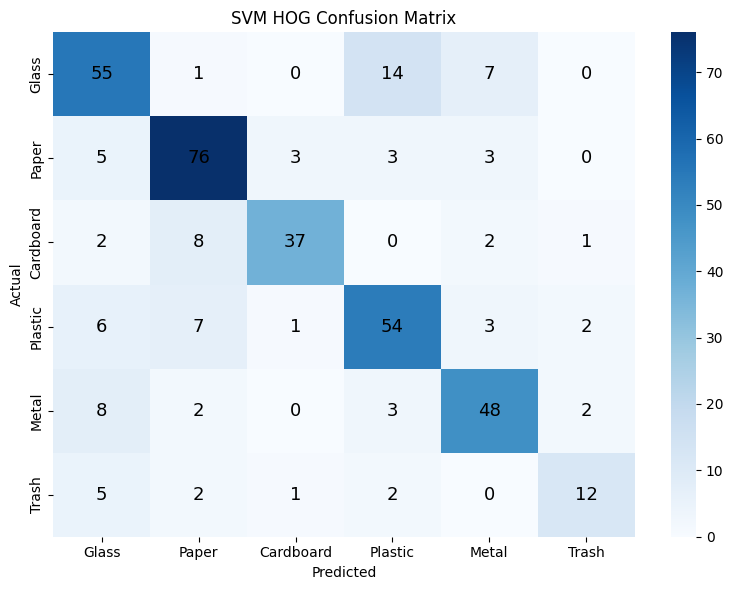

In [24]:
cm = confusion_matrix(y_val, y_pred_svm_hog)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, cmap='Blues',
                 xticklabels=classes, yticklabels=classes,
                 )
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j+0.5, i+0.5, str(cm[i,j]),
                ha='center', va='center',
                color='black', fontsize=13)
plt.title('SVM HOG Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Unknown class rejection svm_hog

In [ ]:
probs = svm_HOG.predict_proba(X_val_pca)#get conf of each image with all classes
max_prob = probs.max(axis=1)# choose the highest conf for each img
y_pred_unknown_svm_hog = y_pred_svm_hog.copy()
y_pred_unknown_svm_hog[max_prob < 0.6] = 6

print('SVM HOG Unknown Rejection:')
for i, cls in enumerate(['Glass','Paper','Cardboard',
                          'Plastic','Metal','Trash','Unknown']):
    count = np.sum(y_pred_unknown_svm_hog == i)
    print(f'{cls}: {count} images')

SVM HOG Unknown Rejection:
Glass: 50 images
Paper: 80 images
Cardboard: 39 images
Plastic: 56 images
Metal: 39 images
Trash: 7 images
Unknown: 104 images


## KNN_HOG Model

In [26]:
knn_hog = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)
knn_hog.fit(X_train_hog, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
y_pred_knn_hog = knn_hog.predict(X_val_hog)
print('k-NN Accuracy HOG:', accuracy_score(y_val, y_pred_knn_hog))
print(classification_report(y_val, y_pred_knn_hog, target_names=classes))


k-NN Accuracy HOG: 0.5626666666666666
              precision    recall  f1-score   support

       Glass       0.63      0.49      0.55        77
       Paper       0.73      0.73      0.73        90
   Cardboard       0.59      0.68      0.63        50
     Plastic       0.42      0.53      0.47        73
       Metal       0.49      0.43      0.46        63
       Trash       0.37      0.32      0.34        22

    accuracy                           0.56       375
   macro avg       0.54      0.53      0.53       375
weighted avg       0.57      0.56      0.56       375



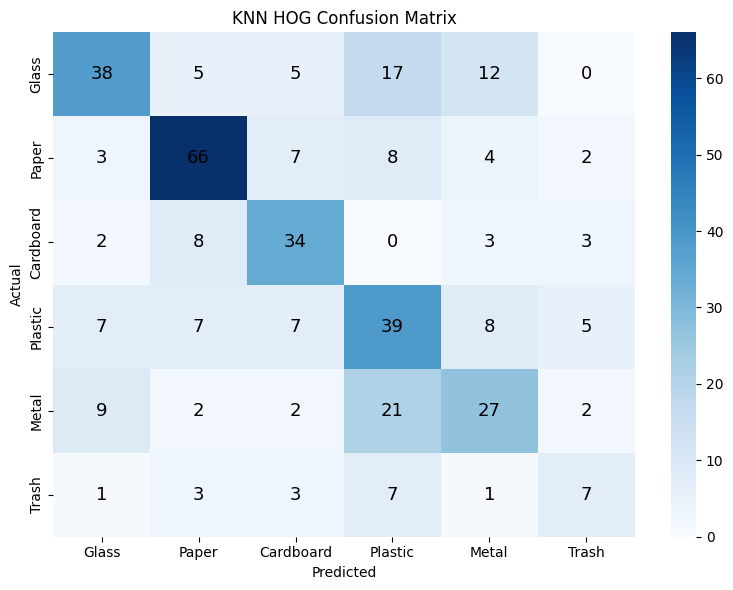

In [28]:
cm = confusion_matrix(y_val, y_pred_knn_hog)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, cmap='Blues',
                 xticklabels=classes, yticklabels=classes,
                 )
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j+0.5, i+0.5, str(cm[i,j]),
                ha='center', va='center',
                color='black', fontsize=13)
plt.title('KNN HOG Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Unknown class rejection knn_hog

In [29]:
probs = knn_hog.predict_proba(X_val_hog)
max_prob = probs.max(axis=1)
y_pred_unknown_knn_hog = y_pred_knn_hog.copy()
y_pred_unknown_knn_hog[max_prob < 0.6] = 6

print('kNN HOG Unknown Rejection:')
for i, cls in enumerate(['Glass','Paper','Cardboard',
                          'Plastic','Metal','Trash','Unknown']):
    count = np.sum(y_pred_unknown_knn_hog == i)
    print(f'{cls}: {count} images')

kNN HOG Unknown Rejection:
Glass: 32 images
Paper: 62 images
Cardboard: 37 images
Plastic: 53 images
Metal: 26 images
Trash: 10 images
Unknown: 155 images


## SVM_lbp Model

In [30]:
svm_lbp = SVC(
    kernel='rbf',# curved boundry best choice for hop and lbp
    C=10,
    probability=True,
    random_state=42
)
svm_lbp.fit(X_train_lbp, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
y_pred_svm_lbp = svm_lbp.predict(X_val_lbp)
print('SVM LBP Accuracy LBP:', accuracy_score(y_val, y_pred_svm_lbp))
print(classification_report(y_val, y_pred_svm_lbp, target_names=classes))


SVM LBP Accuracy LBP: 0.5333333333333333
              precision    recall  f1-score   support

       Glass       0.51      0.53      0.52        77
       Paper       0.68      0.64      0.66        90
   Cardboard       0.66      0.54      0.59        50
     Plastic       0.49      0.53      0.51        73
       Metal       0.48      0.46      0.47        63
       Trash       0.20      0.27      0.23        22

    accuracy                           0.53       375
   macro avg       0.51      0.50      0.50       375
weighted avg       0.55      0.53      0.54       375



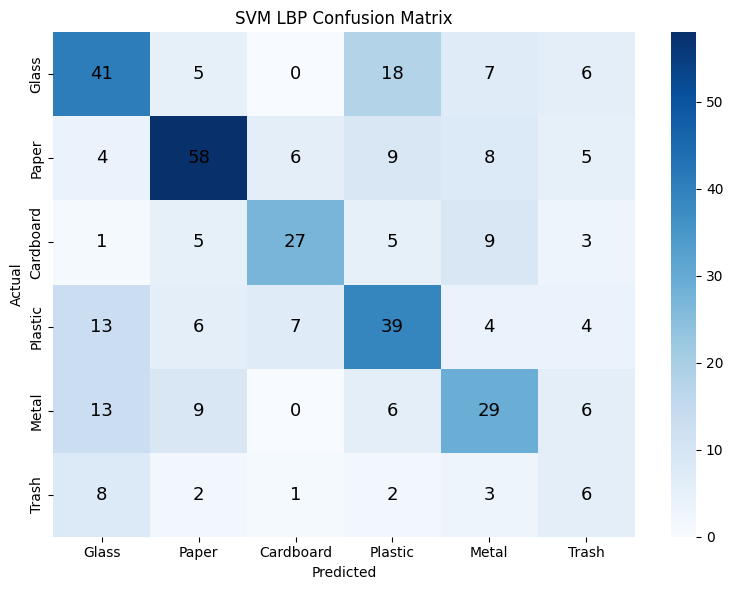

In [32]:
cm = confusion_matrix(y_val, y_pred_svm_lbp)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, cmap='Blues',
                 xticklabels=classes, yticklabels=classes,
                 )
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j+0.5, i+0.5, str(cm[i,j]),
                ha='center', va='center',
                color='black', fontsize=13)
plt.title('SVM LBP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Unknown class rejection svm_lbp

In [33]:
probs = svm_lbp.predict_proba(X_val_lbp)
max_prob = probs.max(axis=1)
y_pred_unknown_svm_lbp = y_pred_svm_lbp.copy()
y_pred_unknown_svm_lbp[max_prob < 0.6] = 6

print('SVM LBP Unknown Rejection:')
for i, cls in enumerate(['Glass','Paper','Cardboard',
                          'Plastic','Metal','Trash','Unknown']):
    count = np.sum(y_pred_unknown_svm_lbp == i)
    print(f'{cls}: {count} images')

SVM LBP Unknown Rejection:
Glass: 14 images
Paper: 39 images
Cardboard: 26 images
Plastic: 19 images
Metal: 18 images
Trash: 7 images
Unknown: 252 images


## KNN_lbp Model

In [34]:
knn_lbp = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)
knn_lbp.fit(X_train_lbp, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [35]:
y_pred_knn_lbp = knn_lbp.predict(X_val_lbp)
print('k-NN LBP Accuracy LBP:', accuracy_score(y_val, y_pred_knn_lbp))
print(classification_report(y_val, y_pred_knn_lbp, target_names=classes))

k-NN LBP Accuracy LBP: 0.48533333333333334
              precision    recall  f1-score   support

       Glass       0.49      0.44      0.47        77
       Paper       0.66      0.56      0.60        90
   Cardboard       0.62      0.58      0.60        50
     Plastic       0.44      0.55      0.49        73
       Metal       0.38      0.37      0.37        63
       Trash       0.18      0.27      0.22        22

    accuracy                           0.49       375
   macro avg       0.46      0.46      0.46       375
weighted avg       0.50      0.49      0.49       375



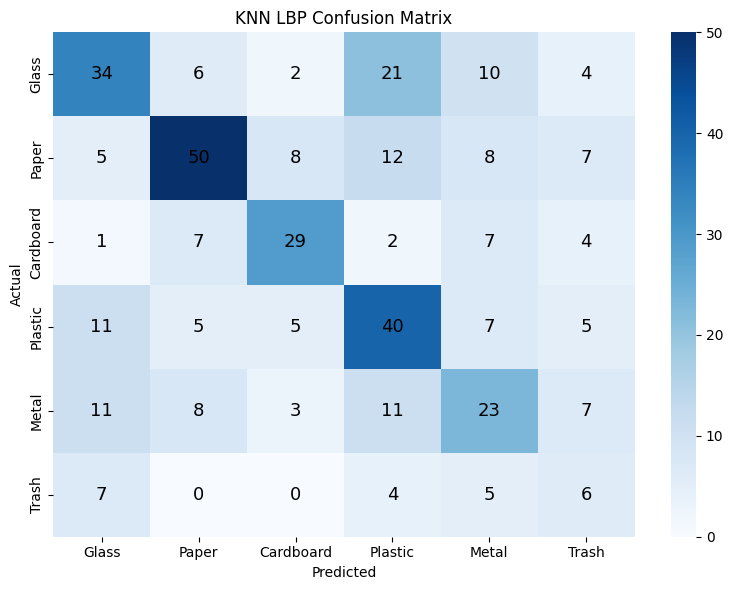

In [36]:
cm = confusion_matrix(y_val, y_pred_knn_lbp)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, cmap='Blues',
                 xticklabels=classes, yticklabels=classes,
                 )
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j+0.5, i+0.5, str(cm[i,j]),
                ha='center', va='center',
                color='black', fontsize=13)
plt.title('KNN LBP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Unknown class rejection knn_lbp

In [ ]:
probs = knn_lbp.predict_proba(X_val_lbp)
max_prob = probs.max(axis=1)
y_pred_unknown_knn_lbp = y_pred_knn_lbp.copy()
y_pred_unknown_knn_lbp[max_prob < 0.6] = 6



print('kNN LBP Unknown Rejection:')
for i, cls in enumerate(['Glass','Paper','Cardboard',
                          'Plastic','Metal','Trash','Unknown']):
    count = np.sum(y_pred_unknown_knn_lbp == i)
    print(f'{cls}: {count} images')

kNN LBP Unknown Rejection:
Glass: 24 images
Paper: 32 images
Cardboard: 22 images
Plastic: 40 images
Metal: 20 images
Trash: 9 images
Unknown: 228 images


In [38]:
import joblib

# Save all 4 models
joblib.dump(svm_HOG,   'svm_hog_model.pkl')
joblib.dump(svm_lbp,   'svm_lbp_model.pkl')
joblib.dump(knn_hog, 'knn_hog_model.pkl')
joblib.dump(knn_lbp,   'knn_lbp_model.pkl')


['knn_lbp_model.pkl']

In [40]:
joblib.dump(sc_hog, 'sc_hog.pkl')
joblib.dump(sc_color, 'sc_color.pkl')
joblib.dump(sc_lbp, 'sc_lbp.pkl')
joblib.dump(pca, 'pca.pkl')

['pca.pkl']

In [41]:
model = joblib.load('svm_hog_model.pkl')
scaler_hog = joblib.load('sc_hog.pkl')
scaler_color = joblib.load('sc_color.pkl')
scaler_lbp = joblib.load('sc_lbp.pkl')
pca = joblib.load('pca.pkl')

In [ ]:
def preprocess_image(image):
    image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) #convert to PIL format and RGB
    image = image.resize((96, 96), Image.Resampling.LANCZOS) #resize to 96x96 as training
    img = np.array(image).astype('float32') / 255.0 #normalize to 0-1 as training
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype('float32') / 255.0 #a gray version for HOG and LBP
    return img, gray

In [ ]:
def extract_features(frame):
    img, gray = preprocess_image(frame)

    #used the same functions in training without it being an array
    
    hog_feat = hog(
        gray.astype('float32'),
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    lbp = local_binary_pattern(gray, 24, 3, method='uniform')
    lbp_feat, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))

    color_feat = np.concatenate([
        np.histogram(img[:, :, c], bins=32, range=(0, 1))[0].astype(float)
        for c in range(3)
    ])
    color_feat = color_feat / (color_feat.sum() + 1e-9)

    hog_scaled = scaler_hog.transform([hog_feat])
    color_scaled = scaler_color.transform([color_feat])
    lbp_scaled = scaler_lbp.transform([lbp_feat])

    combined = np.hstack([hog_scaled, color_scaled, lbp_scaled])
    return pca.transform(combined)

In [ ]:
def predict_with_rejection(model, features, threshold=0.6):
    proba = model.predict_proba(features)[0]
    max_prob = proba.max()
    label_id = int(np.argmax(proba))
    if max_prob < threshold:
        return 6, max_prob
    return label_id, max_prob

In [50]:
ROI_X, ROI_Y, ROI_W, ROI_H = 200, 100, 250, 250 #250x250 box size starting at (200,100)
cap = cv2.VideoCapture(0) #open webcam
while True:
        ret, frame = cap.read()
        if not ret:
            break

        cv2.rectangle(frame, (ROI_X, ROI_Y), (ROI_X + ROI_W, ROI_Y + ROI_H), (0, 255, 0), 2) #draw the box on the frame, 2 is the thickness of the box border, default color is green
        roi = frame[ROI_Y:ROI_Y + ROI_H, ROI_X:ROI_X + ROI_W]
        features = extract_features(roi)
        class_id, confidence = predict_with_rejection(model, features, threshold=0.6)
        label = f"{classes[class_id] if class_id < len(classes) else 'Unknown'} ({confidence:.2f})"

        color = (0, 0, 255) if class_id == 6 else (0, 255, 0) #red for unknown, green for known
        cv2.putText(frame, label, (ROI_X, ROI_Y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
        cv2.putText(frame, 'Place item in box', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow('MSI System - Real Time', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        if cv2.getWindowProperty('MSI System - Real Time', cv2.WND_PROP_VISIBLE) < 1:  # EXIT WHEN CLICKED
            break

cap.release()
cv2.destroyAllWindows()

c:\Users\To\miniconda3\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
c:\Users\To\miniconda3\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
c:\Users\To\miniconda3\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
c:\Users\To\minicon